# Inference of the relation between $r_h$ and $\sigma_v$

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import corner
from glob import glob
import os

%matplotlib inline

In [12]:
res_path = '../result/10D/'
fig_path = '../figure/'
data_path = '../data/'




In [18]:


df = pd.read_csv(data_path+"dwarfs_meanrh_sigma_dw.txt")
df

,#dwarf,best_rh,best_sigma_dw,un_sigma_dw
0,0,94.4,4.2,1.3
1,1,442.2,10.0,1.6
2,2,61.8,5.6,0.8
3,3,393.2,6.8,0.8
4,4,152.1,5.8,0.7
5,5,104.3,5.6,1.3
6,6,226.1,5.7,0.8
7,7,134.4,10.2,1.4
8,8,168.2,8.1,1.1
9,9,181.8,8.0,3.2


In [35]:
def dvr_model(a, b, rh):
    dvr = a * rh + b
    return dvr


# for each pair of (a, b), calculate the loglikelihood assuming the unceratinty of relation is sigma 
def log_Likelihood(theta, rh, dvr, un_dvr):

    a, b, sigma = theta
    sigma_new = np.sqrt(sigma**2.+un_dvr**2.)

    
    L = 1/np.sqrt(2*np.pi)/sigma_new * np.exp(-0.5*(dvr_model(a, b, rh) - dvr)**2./ sigma_new**2.)
    logL = np.sum(np.log(L))

    return logL

In [102]:
rh_mod = np.linspace(0, 1200, 1000)
a0 = 0.005
b0 = 5.
dvr_mod = dvr_model(a0, b0, rh_mod)

(0.0, 25.0)

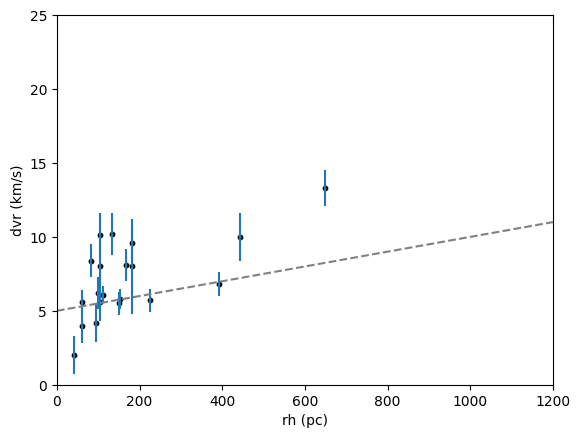

In [103]:
plt.figure()


plt.errorbar(df["best_rh"], df["best_sigma_dw"], yerr=df['un_sigma_dw'], fmt=" ")
plt.scatter(df["best_rh"], df["best_sigma_dw"], color='k', s=10, label='All dwarfs')

plt.plot(rh_mod, dvr_mod, color='.5', label='model', ls="dashed")
plt.xlabel("rh (pc)")
plt.ylabel("dvr (km/s)")
plt.xlim(0, 1200)
plt.ylim(0, 25)





In [125]:
a0 = 0.005
b0 = 5.
sigma0 = 2.

param0 = a0, b0, sigma0

logL0 = log_Likelihood(param0, df["best_rh"], df["best_sigma_dw"], df['un_sigma_dw'])

# refine the following steps based on the uncertainties of the results
step_a = 1e-3
step_b = .5
step_sigma = .5
nsteps= 50000

samples = np.zeros((nsteps, 5))
accept = 1

In [126]:
for i in range(nsteps):

    param1 = param0
    logL1 = logL0

    samples[i, :3] = param1
    samples[i, 3] = logL1
    samples[i, 4] = accept

    accept = 0

    a1, b1, sigma1 = param1
    a1 = a1 + np.random.normal(0, step_a)   
    b1 = b1 + np.random.normal(0, step_b)
    sigma1 = sigma1 + np.random.normal(0, step_sigma)
   
    param1 = a1, b1, sigma1

    if (0 <sigma1) :
    
        logL1 = log_Likelihood(param1, df["best_rh"], df["best_sigma_dw"], df['un_sigma_dw'])      

        if logL1 > logL0:

            param0 = param1
            logL0 = logL1
            accept = 1

        else:

            random = np.random.uniform(0, 1)
            if (logL1-logL0) > np.log(random):

                param0 = param1
                logL0 = logL1
                accept = 1

In [127]:
# Check the acceptance rate of the MCMC (should be around 20%)
ind_accept = samples[:, -1] == 1
print ("acceptance rate", len(samples[ind_accept, -1])/nsteps)
samples =  samples[int(nsteps*0.2):]

acceptance rate 0.4977


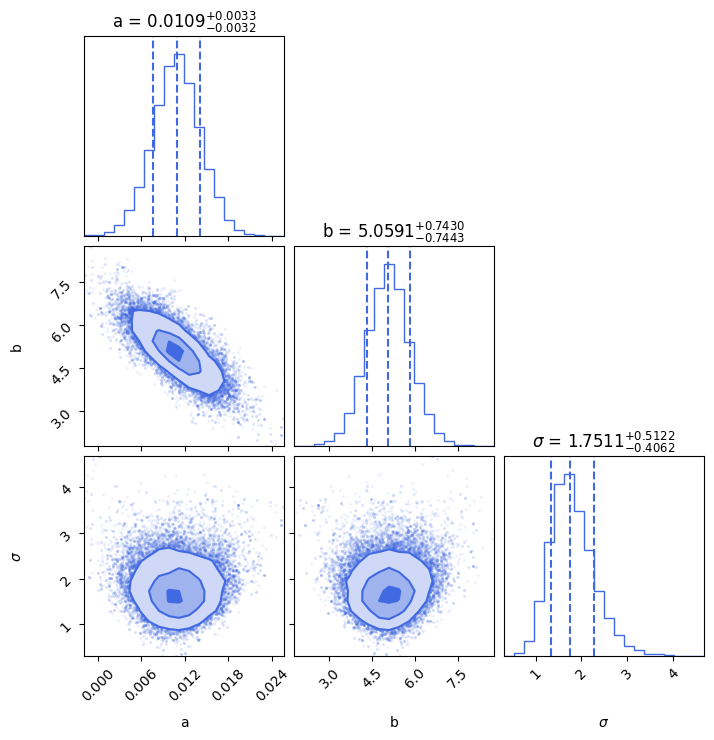

In [128]:
fig = corner.corner(
    samples[:,:3],
    labels=[r"a", r"b", r"$\sigma$"],
    show_titles=True,
    title_fmt=".4f",
    quantiles=[0.16, 0.5, 0.84],
    levels=(0.16, 0.5, 0.84),
    color="royalblue",
    fill_contours=True)


# plt.savefig(fig_path+'linear_relation_rh_sigma.png', dpi=300)

In [129]:
ind_best = np.argmax(samples[:, 3])
print (samples[ind_best, :3])

[0.01098636 5.01751131 1.48216747]


(0.0, 25.0)

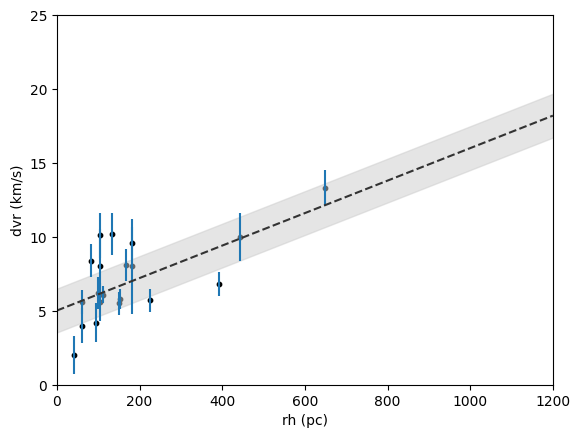

In [131]:
rh_mod = np.linspace(0, 1200, 1000)

dvr_mod = dvr_model(samples[ind_best, 0], samples[ind_best, 1], rh_mod)

plt.figure()
plt.errorbar(df["best_rh"], df["best_sigma_dw"], yerr=df['un_sigma_dw'], fmt=" ")
plt.scatter(df["best_rh"], df["best_sigma_dw"], color='k', s=10, label='All dwarfs')

plt.plot(rh_mod, dvr_mod, color='.2', label='model', ls="dashed")
plt.fill_between(rh_mod, dvr_mod-samples[ind_best, 2], dvr_mod+samples[ind_best, 2], color='.8', alpha=0.5, label='1 sigma')

plt.xlabel("rh (pc)")
plt.ylabel("dvr (km/s)")
plt.xlim(0, 1200)
plt.ylim(0, 25)

In [132]:
indices = np.random.choice(len(samples), 20, replace=False)
print(indices.shape)
samples1 = samples[indices]


(20,)


(0.0, 25.0)

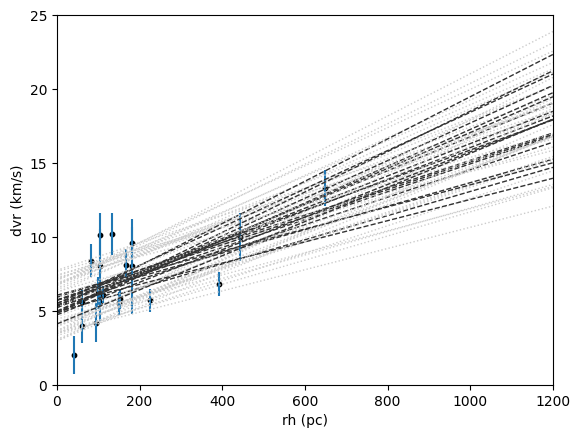

In [134]:
rh_mod = np.linspace(0, 1200, 1000)

plt.figure()

plt.errorbar(df["best_rh"], df["best_sigma_dw"], yerr=df['un_sigma_dw'], fmt=" ")
plt.scatter(df["best_rh"], df["best_sigma_dw"], color='k', s=10, label='All dwarfs')

for i in range(len(samples1)):
    dvr_mod = dvr_model(samples1[i, 0], samples1[i, 1], rh_mod)

    plt.plot(rh_mod, dvr_mod, color='.2', lw=1, label='model', ls="dashed")
    plt.plot(rh_mod, dvr_mod-samples[i, 2], lw=1, ls="dotted", color='.8')
    plt.plot(rh_mod, dvr_mod+samples[i, 2], lw=1, ls="dotted", color='.8')

plt.xlabel("rh (pc)")
plt.ylabel("dvr (km/s)")
plt.xlim(0, 1200)
plt.ylim(0, 25)